In [ ]:
import scipy
scipy.__version__

'1.4.1'


**cluster**	Алгоритмы кластерного анализа

**constants**	Физические и математические константы

**fftpack**	Быстрое преобразование Фурье

**integrate**	Решения интегральных и обычных дифференциальных уравнений

**interpolate**	Интерполяция и сглаживание сплайнов

**io**	Ввод и вывод

**linalg**	Линейная алгебра

**ndimage**	N-размерная обработка изображений

**odr**	Метод ортогональных расстояний

**optimize**	Оптимизация и численное решение уравнений

**signal**	Обработка сигналов

**sparse**	Разреженные матрицы

**spatial**	Разреженные структуры данных

**special**	Специальные функции

**stats**	Статистические распределения и функции

**Интегрирование**

quad - взятие интеграла

dblquad - взятие двойного интеграла

tplquad - взятие тройного интергала

fixed_quad - интегрирование квадратур Гаусса порядка n

quadrature - интегрирование с заданным допуском и использованием квадратуры Гаусса

romberg - интегрирование методом Ромберга


**Методы интегрирования **


trapz -  правило трапеции

cumtrapz - правило трапеции для кумулятивного вычисления интеграла

simps -  правило Симпсона

romb -  интегрирование методом Ромберга из (2 ** k + 1) равномерно распределенных образцов

In [ ]:
from scipy import special
from scipy import integrate
import numpy as np
a = lambda x:special.exp10(x)
b = scipy.integrate.quad(a, 0, 1) #-np.inf +np.inf
b

(3.9086503371292665, 4.3394735994897923e-14)

In [ ]:
import scipy.integrate as integrate
import scipy.special as special
result = integrate.quad(lambda x: special.jv(2.5,x), 0, 4.5) #ф-я Бесселя
result

(1.1178179380783253, 7.866317182537226e-09)

In [ ]:
from scipy.integrate import quad
def integrand(x, a, b):
    return a*x**2 + b
a=2
b=2
result=quad(integrand, 0, 1, args=(a,b))
result

(2.6666666666666665, 2.9605947323337504e-14)

In [ ]:
from scipy.integrate import quad
import numpy as np
def integrand(t, n, x):
    return np.exp(-x*t) / t**n

def expint(n, x):
    return quad(integrand, 1, np.inf, args=(n, x))[0]

vec_expint = np.vectorize(expint)
vec_expint(3, np.arange(1.0, 4.0, 0.5))


array([0.10969197, 0.05673949, 0.03013338, 0.01629537, 0.00893065,
       0.00494538])

In [ ]:
expint

<function __main__.expint>

In [ ]:
vec_expint

In [ ]:
special.expn(3, np.arange(1.0,4.0,0.5))

array([0.10969197, 0.05673949, 0.03013338, 0.01629537, 0.00893065,
       0.00494538])

In [ ]:
result = quad(lambda x: expint(3, x), 0, np.inf)
result

(0.33333333325010883, 2.8604069921197956e-09)

In [ ]:
# двойной интеграл
a = lambda y, x: x*y**2
b = lambda x: 1
c = lambda x: -1
result=integrate.dblquad(a, 0, 2, b, c)
result

(-1.3333333333333335, 1.4802973661668755e-14)

In [ ]:
from scipy.integrate import quad, dblquad
result = dblquad(lambda x, y: x*y**2, 0, 0.5, lambda x: 0, lambda x: 1-2*x)

result

(0.0020833333333333333, 8.673617379884035e-17)

In [ ]:
from scipy import integrate
N = 5
def f(t, x):
   return np.exp(-x*t) / t**N
result=integrate.nquad(f, [[1, np.inf],[0, np.inf]])
result

(0.2000000000189363, 1.3682975855986131e-08)

In [ ]:
from scipy import integrate
def f(x, y):
    return x*y

def bounds_y():
    return [0, 0.5]
def bounds_x(y):
    return [0, 1-2*y]
result=integrate.nquad(f, [bounds_x, bounds_y])
result

(0.010416666666666668, 4.101620128472366e-16)

In [ ]:
def f1(x):
   return x**2
def f2(x):
   return x**3
x = np.array([1,3,4]) #интегрирование от 1 до 4
y1 = f1(x)
from scipy.integrate import simps
result = simps(y1, x)
result

21.0

In [ ]:
y2 = f2(x)
result = integrate.simps(y2, x)
result # а вот тут не правильно -  из-за степени полинома больше 2

61.5

** Оптимизация**

In [ ]:
# Функия Розенброка
import numpy as np
from scipy.optimize import rosen
a = 1.2 * np.arange(5)
a


array([0. , 1.2, 2.4, 3.6, 4.8])

In [ ]:
rosen(a)
#Безусловная минимизация скалярной функции нескольких переменных
#подробнее https://habr.com/ru/post/439288/ и https://habr.com/ru/company/ods/blog/448054/

7371.0399999999945

In [ ]:
def rosen2(x):
    """The Rosenbrock function"""
    return np.sum(100.0*(x[1:]-x[:-1]**2.0)**2.0 + (1-x[:-1])**2.0, axis=0)
rosen2(a)

7371.0399999999945

In [ ]:
#алгоритм Нелдера — Мида
from scipy import optimize
a = [2.4, 1.7, 3.1, 2.9, 0.2]
b = optimize.minimize(optimize.rosen, a, method='Nelder-Mead')
b.x

array([0.96570182, 0.93255069, 0.86939478, 0.75497872, 0.56793357])

In [ ]:
b

 final_simplex: (array([[0.96570182, 0.93255069, 0.86939478, 0.75497872, 0.56793357],
       [0.96572026, 0.93264154, 0.86936943, 0.75499743, 0.56793092],
       [0.96574802, 0.93263174, 0.86948823, 0.75502334, 0.56791589],
       [0.96575679, 0.93261393, 0.86937052, 0.75502138, 0.5679214 ],
       [0.96575237, 0.93259073, 0.86937829, 0.7548972 , 0.56793349],
       [0.96567428, 0.93255106, 0.86942025, 0.75496516, 0.56793388]]), array([0.08332508, 0.08332508, 0.08332568, 0.08332607, 0.08332695,
       0.08332754]))
           fun: 0.08332507501465103
       message: 'Optimization terminated successfully.'
          nfev: 260
           nit: 150
        status: 0
       success: True
             x: array([0.96570182, 0.93255069, 0.86939478, 0.75497872, 0.56793357])

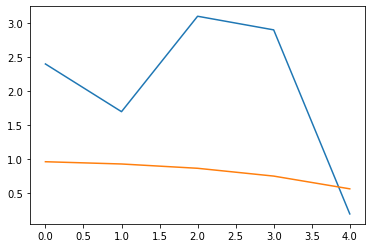

In [ ]:
import matplotlib
import  matplotlib.pyplot as plt
plt.plot(a)
plt.plot(b.x)
plt.show()

In [ ]:
import numpy as np
from scipy.optimize import minimize


def rosen(x):
    """The Rosenbrock function"""
    return sum(100.0*(x[1:]-x[:-1]**2.0)**2.0 + (1-x[:-1])**2.0)


x0 = np.array([1.3, 0.7, 0.8, 1.9, 1.2])
res = minimize(rosen, x0, method='nelder-mead',options={'xatol': 1e-8, 'disp': True})
res.x

Optimization terminated successfully.
         Current function value: 0.000000
         Iterations: 339
         Function evaluations: 571


array([1., 1., 1., 1., 1.])

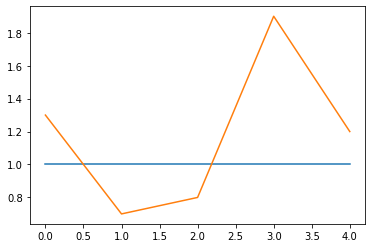

In [ ]:
plt.plot(res.x)
plt.plot(x0)
plt.show()

In [ ]:
#Метод Пауэлла
x0 = np.array([1.3, 0.7, 0.8, 1.9, 1.2])
res = minimize(rosen, x0, method='powell', options={'xtol': 1e-8, 'disp': True})
print(res.x)

Optimization terminated successfully.
         Current function value: 0.000000
         Iterations: 19
         Function evaluations: 1622
[1. 1. 1. 1. 1.]


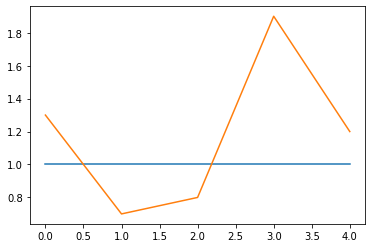

In [ ]:
plt.plot(res.x)
plt.plot(x0)
plt.show()

`ftol` termination condition is satisfied.
Function evaluations 131, initial cost 4.4383e+00, final cost 1.5375e-04, first-order optimality 4.52e-08.


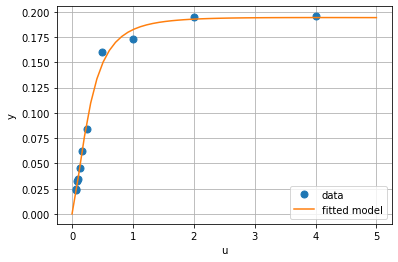

In [ ]:
from scipy.optimize import least_squares


def model(x, u):
    return x[0] * (u ** 2 + x[1] * u) / (u ** 2 + x[2] * u + x[3])


def fun(x, u, y):
    return model(x, u) - y


def jac(x, u, y):
    J = np.empty((u.size, x.size))
    den = u ** 2 + x[2] * u + x[3]
    num = u ** 2 + x[1] * u
    J[:, 0] = num / den
    J[:, 1] = x[0] * u / den
    J[:, 2] = -x[0] * num * u / den ** 2
    J[:, 3] = -x[0] * num / den ** 2
    return J

u = np.array([4.0, 2.0, 1.0, 5.0e-1, 2.5e-1, 1.67e-1, 1.25e-1, 1.0e-1,
              8.33e-2, 7.14e-2, 6.25e-2])
y = np.array([1.957e-1, 1.947e-1, 1.735e-1, 1.6e-1, 8.44e-2, 6.27e-2,
              4.56e-2, 3.42e-2, 3.23e-2, 2.35e-2, 2.46e-2])
x0 = np.array([2.5, 3.9, 4.15, 3.9])
res = least_squares(fun, x0, jac=jac, bounds=(0, 100), args=(u, y), verbose=1)



import matplotlib.pyplot as plt
u_test = np.linspace(0, 5)
y_test = model(res.x, u_test)
plt.plot(u, y, 'o', markersize=7, label='data')
plt.plot(u_test, y_test, label='fitted model')
plt.xlabel("u")
plt.ylabel("y")
plt.legend(loc='lower right')
plt.grid()
plt.show()

In [ ]:

res.x

array([0.192806  , 0.19130332, 0.12306046, 0.13607205])

**Функции интерполяции**

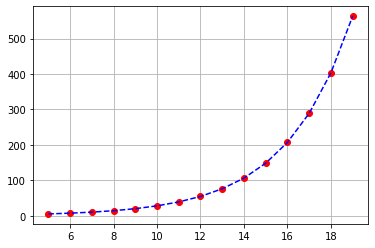

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

from scipy import interpolate
x = np.arange(5, 20)
y = np.exp(x/3.0)
f = interpolate.interp1d(x, y)
x1 = np.arange(5, 20)
y1 = f(x1)   # использовать функцию интерполяции, возвращаемую `interp1d`
plt.plot(x, y, 'ro',  x1, y1, 'b--')
plt.grid()
plt.show()

In [ ]:
x,y

(array([ 5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]),
 array([  5.29449005,   7.3890561 ,  10.3122585 ,  14.3919161 ,
         20.08553692,  28.03162489,  39.121284  ,  54.59815003,
         76.19785657, 106.3426754 , 148.4131591 , 207.12724889,
        289.06936212, 403.42879349, 563.03023684]))

In [ ]:
x1,y1

(array([10, 11, 12, 13, 14]),
 array([ 28.03162489,  39.121284  ,  54.59815003,  76.19785657,
        106.3426754 ]))

In [ ]:
f

In [ ]:
#interp1d  ind kможет принимать значения ‘linear’ , ‘nearest’ , ‘zero’ , ‘slinear’ , ‘quadratic’ , ‘cubic’
#nearest "snaps" до ближайшей точки данных.
#zero -  сплайн нулевого порядка. Его ценность в любой момент - это последняя видимая необработанная ценность
#linear выполняет линейную интерполяцию
#slinear использует сплайн первого порядка. Они используют другой код и могут давать похожие, но слегка отличающиеся результаты
#quadratic использует сплайн-интерполяцию второго порядка
#cubic использует сплайн-интерполяцию третьего порядка

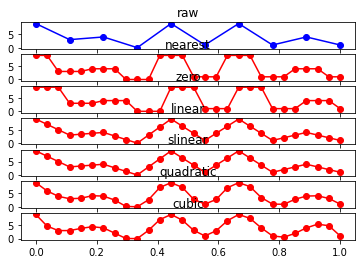

In [ ]:
import numpy as np

np.random.seed(6)
kinds = ('nearest', 'zero', 'linear', 'slinear', 'quadratic', 'cubic')

n = 10
x = np.linspace(0, 1, n)
y = np.random.randint(10, size=(n,))

new_x = np.linspace(0, 1, 28)

fig, axs = plt.subplots(nrows=len(kinds)+1, sharex=True)
axs[0].plot(x, y, 'bo-')
axs[0].set_title('raw')
for ax, kind in zip(axs[1:], kinds):
    new_y = interpolate.interp1d(x, y, kind=kind)(new_x)
    ax.plot(new_x, new_y, 'ro-')
    ax.set_title(kind)


plt.show()

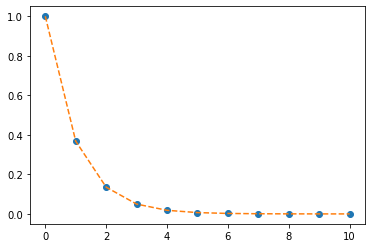

In [ ]:
from scipy.interpolate import interp1d

x = np.linspace(0, 10, num=11, endpoint=True)
#y = np.tan(-x**3/9.0)
y=np.exp(-x)
f = interp1d(x, y)
f2 = interp1d(x, y, kind='linear')
f3 = interp1d(x, y, kind='cubic')
plt.plot(x, y, 'o', x, f3(x), '--')
plt.show()
#https://dev-gang.ru/article/izmenit-razmer-risunka-v-matplotlib-9btqsjj4ff/

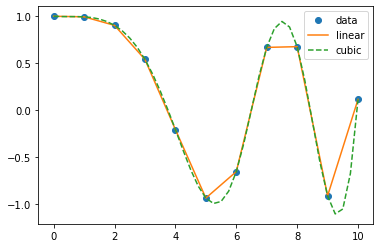

In [ ]:
from scipy.interpolate import interp1d

x = np.linspace(0, 10, num=11, endpoint=True)
y = np.cos(-x**2/9.0)
f = interp1d(x, y)
f2 = interp1d(x, y, kind='cubic')

xnew = np.linspace(0, 10, num=41, endpoint=True)

#np.linspace(0, 2, 9)  # array([  0. ,  0.25,  0.5 ,  0.75, 1. , 1.25, 1.5 , 1.75, 2. ]) #9 чисел от 0 до 2 включительно
#np.arange(10, 30, 5)  #array([10, 15, 20, 25])
#  def f1(i, j):  return 3 * i + j np.fromfunction(f1, (3, 4)) #применят функцию ко всем элементам массива

import matplotlib.pyplot as plt
plt.plot(x, y, 'o', xnew, f(xnew), '-', xnew, f2(xnew), '--')
plt.legend(['data', 'linear', 'cubic'], loc='best')
plt.show()

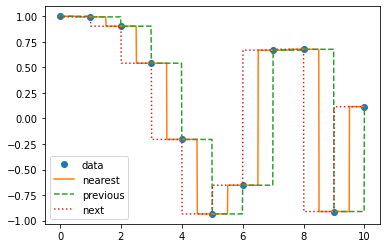

In [ ]:
from scipy.interpolate import interp1d

x = np.linspace(0, 10, num=11, endpoint=True)
y = np.cos(-x**2/9.0)
f1 = interp1d(x, y, kind='nearest')
f2 = interp1d(x, y, kind='previous')
f3 = interp1d(x, y, kind='next')

xnew = np.linspace(0, 10, num=1001, endpoint=True)
import matplotlib.pyplot as plt
plt.plot(x, y, 'o')
plt.plot(xnew, f1(xnew), '-', xnew, f2(xnew), '--', xnew, f3(xnew), ':')
plt.legend(['data', 'nearest', 'previous', 'next'], loc='best')
plt.show()

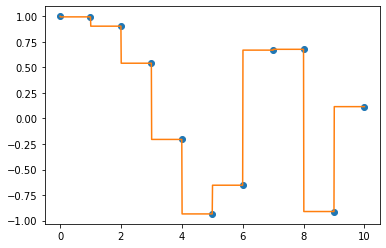

In [ ]:
x = np.linspace(0, 10, num=11, endpoint=True)
y = np.cos(-x**2/9.0)
f1 = interp1d(x, y, kind='nearest')
f2 = interp1d(x, y, kind='previous')
f3 = interp1d(x, y, kind='next')

xnew = np.linspace(0, 10, num=1001, endpoint=True)
import matplotlib.pyplot as plt
plt.plot(x, y, 'o')
#plt.plot(xnew, f1(xnew), '-', xnew, f2(xnew), '--', xnew, f3(xnew), ':')
plt.plot(xnew, f3(xnew), '-',)
plt.show()

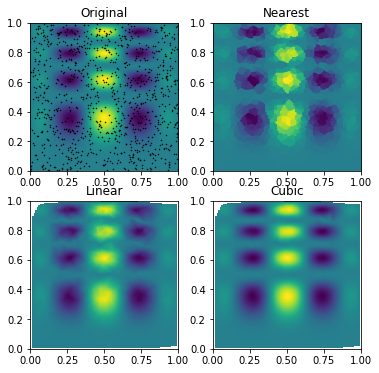

In [ ]:
# в случае нерегулярных данных
from scipy.interpolate import griddata
import matplotlib.pyplot as plt

def func(x, y):
    return x*(1-x)*np.cos(4*np.pi*x) * np.sin(4*np.pi*y**2)**2
grid_x, grid_y = np.mgrid[0:1:100j, 0:1:200j]
points = np.random.rand(1000, 2)
values = func(points[:,0], points[:,1])

grid_z0 = griddata(points, values, (grid_x, grid_y), method='nearest')
grid_z1 = griddata(points, values, (grid_x, grid_y), method='linear')
grid_z2 = griddata(points, values, (grid_x, grid_y), method='cubic')


plt.subplot(221)
plt.imshow(func(grid_x, grid_y).T, extent=(0,1,0,1), origin='lower')
plt.plot(points[:,0], points[:,1], 'k.', ms=1)
plt.title('Original')
plt.subplot(222)
plt.imshow(grid_z0.T, extent=(0,1,0,1), origin='lower')
plt.title('Nearest')
plt.subplot(223)
plt.imshow(grid_z1.T, extent=(0,1,0,1), origin='lower')
plt.title('Linear')
plt.subplot(224)
plt.imshow(grid_z2.T, extent=(0,1,0,1), origin='lower')
plt.title('Cubic')
plt.gcf().set_size_inches(6, 6)
plt.show()

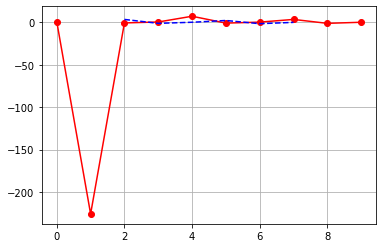

In [ ]:
from scipy import interpolate
import matplotlib.pyplot as plt
x = np.arange(0,10)
y = np.arange(10,25)
x1, y1 = np.meshgrid(x, y)
z = np.tan(x1+y1)
f = interpolate.interp2d(x, y, z, kind='cubic')
x2 = np.arange(2,8)
y2 = np.arange(15,20)
z2 = f(x2, y2)
plt.grid()
plt.plot(x, z[0, :], 'ro-', x2, z2[0, :], 'b--')
plt.show()

In [ ]:
x1,y1

(array([[0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
        [0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
        [0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
        [0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
        [0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
        [0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
        [0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
        [0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
        [0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
        [0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
        [0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
        [0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
        [0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
        [0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
        [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]]),
 array([[10, 10, 10, 10, 10, 10, 10, 10, 10, 10],
        [11, 11, 11, 11, 11, 11, 11, 11, 11, 11],
        [12, 12, 12, 12, 12, 12, 12, 12, 12, 12],
        [13, 13, 13, 13, 13, 13, 13, 13, 13, 13],
        [14, 14, 14, 14, 14, 14, 14, 14, 14, 14],
        [15, 15, 15, 15, 15, 15, 15, 15, 15, 15],
        [16, 16, 16, 16, 16, 16, 16, 16, 16, 16],
        [17, 17, 17, 17, 17, 17, 17, 17, 17, 17]

In [ ]:
x,y

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 array([10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]))

In [ ]:
x2,y2

(array([2, 3, 4, 5, 6, 7]), array([15, 16, 17, 18, 19]))

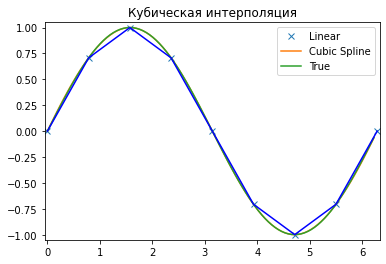

In [ ]:
#интерполяция сплайнами
import numpy as np
import matplotlib.pyplot as plt
from scipy import interpolate
#Cubic-spline

x = np.arange(0, 2*np.pi+np.pi/4, 2*np.pi/8)
y = np.sin(x)
tck = interpolate.splrep(x, y, s=0)
xnew = np.arange(0, 2*np.pi, np.pi/50)

ynew = interpolate.splev(xnew, tck, der=0)
#ynew = interpolate.splev(xnew, tck, der=0)

plt.figure()
plt.plot(x, y, 'x', xnew, ynew, xnew, np.sin(xnew), x, y, 'b')

plt.legend(['Linear', 'Cubic Spline', 'True'])
plt.axis([-0.05, 6.33, -1.05, 1.05])
plt.title('Кубическая интерполяция')
plt.show()

In [ ]:
 x,y

(array([0.        , 0.78539816, 1.57079633, 2.35619449, 3.14159265,
        3.92699082, 4.71238898, 5.49778714, 6.28318531]),
 array([ 0.00000000e+00,  7.07106781e-01,  1.00000000e+00,  7.07106781e-01,
         1.22464680e-16, -7.07106781e-01, -1.00000000e+00, -7.07106781e-01,
        -2.44929360e-16]))

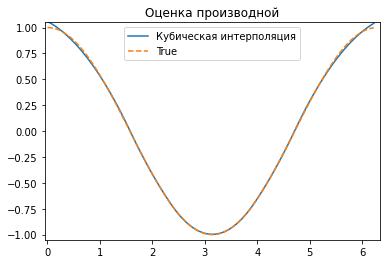

In [ ]:
yder = interpolate.splev(xnew, tck, der=1)
plt.figure()
plt.plot(xnew, yder, xnew, np.cos(xnew),'--')
plt.legend(['Кубическая интерполяция', 'True'])
plt.axis([-0.05, 6.33, -1.05, 1.05])
plt.title('Оценка производной')
plt.show()

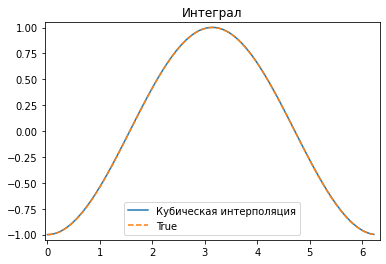

In [ ]:
def integ(x, tck, constant=-1):
    x = np.atleast_1d(x)
    out = np.zeros(x.shape, dtype=x.dtype)
    for n in range(len(out)):
        out[n] = interpolate.splint(0, x[n], tck)
    out += constant
    return out


yint = integ(xnew, tck)
plt.figure()
plt.plot(xnew, yint, xnew, -np.cos(xnew), '--')
plt.legend(['Кубическая интерполяция', 'True'])
plt.axis([-0.05, 6.33, -1.05, 1.05])
plt.title('Интеграл')

plt.show()

In [ ]:
tck

(array([0.        , 0.        , 0.        , 0.        , 1.57079633,
        2.35619449, 3.14159265, 3.92699082, 4.71238898, 6.28318531,
        6.28318531, 6.28318531, 6.28318531]),
 array([ 3.44265545e-18,  5.54608516e-01,  1.21921009e+00,  7.83113675e-01,
         2.45205789e-16, -7.83113675e-01, -1.21921009e+00, -5.54608516e-01,
        -2.44929360e-16,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00]),
 3)

In [ ]:
interpolate.sproot(tck) #корни сплайна

array([3.14159265])

In [ ]:
x = np.linspace(-np.pi/4, 2.*np.pi + np.pi/4, 21)
y = np.sin(x)
tck = interpolate.splrep(x, y, s=0)
interpolate.sproot(tck) # корни на диапазоне значений


array([-2.22044605e-16,  3.14159265e+00,  6.28318531e+00])

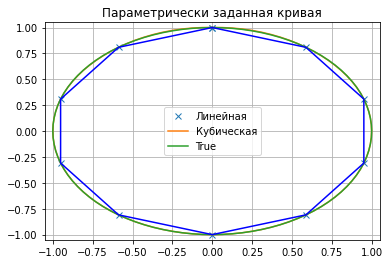

In [ ]:
# Параметрическая кривая
t = np.arange(0, 1.1, .1)
x = np.sin(2*np.pi*t)
y = np.cos(2*np.pi*t)
tck, u = interpolate.splprep([x, y], s=0)
unew = np.arange(0, 1.01, 0.01)
out = interpolate.splev(unew, tck)
plt.figure()
plt.plot(x, y, 'x', out[0], out[1], np.sin(2*np.pi*unew), np.cos(2*np.pi*unew), x, y, 'b')
plt.legend(['Линейная', 'Кубическая', 'True'])
plt.axis([-1.05, 1.05, -1.05, 1.05])
plt.grid()
plt.title('Параметрически заданная кривая')
plt.show()

In [ ]:
tck, u = interpolate.splprep([x, y], s=0)
tck

[array([0. , 0. , 0. , 0. , 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 1. , 1. ,
        1. , 1. ]),
 [array([-1.03279664e-17,  4.29462711e-01,  1.01668733e+00,  1.01553643e+00,
          6.27793771e-01,  3.45794451e-16, -6.27793771e-01, -1.01553643e+00,
         -1.01668733e+00, -4.29462711e-01, -2.44929360e-16]),
  array([ 1.        ,  1.01508954,  0.5513804 , -0.33027953, -0.86394927,
         -1.06802537, -0.86394927, -0.33027953,  0.5513804 ,  1.01508954,
          1.        ])],
 3]

In [ ]:
u

array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ])

In [ ]:
out

[array([-1.03279664e-17,  6.41066353e-02,  1.27476032e-01,  1.89940644e-01,
         2.51332929e-01,  3.11485341e-01,  3.70230336e-01,  4.27400369e-01,
         4.82827896e-01,  5.36345372e-01,  5.87785252e-01,  6.36979993e-01,
         6.83762049e-01,  7.27963877e-01,  7.69417931e-01,  8.07956667e-01,
         8.43412540e-01,  8.75618006e-01,  9.04405520e-01,  9.29607539e-01,
         9.51056516e-01,  9.68613696e-01,  9.82255469e-01,  9.91987015e-01,
         9.97813513e-01,  9.99740142e-01,  9.97772081e-01,  9.91914509e-01,
         9.82172605e-01,  9.68551547e-01,  9.51056516e-01,  9.29716299e-01,
         9.04654114e-01,  8.76016792e-01,  8.43951160e-01,  8.08604047e-01,
         7.70122280e-01,  7.28652689e-01,  6.84342102e-01,  6.37337347e-01,
         5.87785252e-01,  5.35848184e-01,  4.81750655e-01,  4.25732718e-01,
         3.68034422e-01,  3.08895821e-01,  2.48556963e-01,  1.87257901e-01,
         1.25238686e-01,  6.27393686e-02, -1.94289029e-16, -6.27393686e-02,
        -1.2

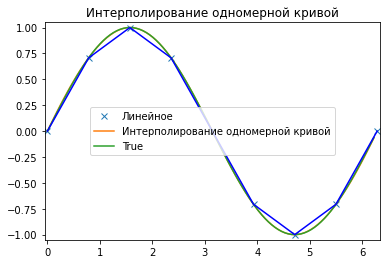

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import interpolate
#InterpolatedUnivariateSpline

x = np.arange(0, 2*np.pi+np.pi/4, 2*np.pi/8)
y = np.sin(x)
s = interpolate.InterpolatedUnivariateSpline(x, y)
xnew = np.arange(0, 2*np.pi, np.pi/50)
ynew = s(xnew)

plt.figure()
plt.plot(x, y, 'x', xnew, ynew, xnew, np.sin(xnew), x, y, 'b')
plt.legend(['Линейное', 'Интерполирование одномерной кривой', 'True'])
plt.axis([-0.05, 6.33, -1.05, 1.05])
plt.title('Интерполирование одномерной кривой')
plt.show()

In [ ]:
x = np.arange(10)
s = interpolate.InterpolatedUnivariateSpline(x, x)
s.get_knots()

array([0., 2., 3., 4., 5., 6., 7., 9.])

In [ ]:


knt = s.get_knots()
s1 = interpolate.LSQUnivariateSpline(x, x, knt[1:-1])    # Chop 1st and last knot
s1.get_knots()

array([0., 2., 3., 4., 5., 6., 7., 9.])

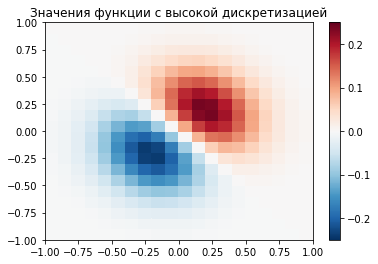

In [ ]:
import numpy as np
from scipy import interpolate
import matplotlib.pyplot as plt
#сетка 20 на 20
# Функция diff() возвращает n-ю разность элементов массива, которая так же может быть вычислена вдоль указанной оси
x_edges, y_edges = np.mgrid[-1:1:21j, -1:1:21j]
x = x_edges[:-1, :-1] + np.diff(x_edges[:2, 0])[0] / 2.
y = y_edges[:-1, :-1] + np.diff(y_edges[0, :2])[0] / 2.
z = (x+y) * np.exp(-6.0*(x*x+y*y))

plt.figure()
lims = dict(cmap='RdBu_r', vmin=-0.25, vmax=0.25)
plt.pcolormesh(x_edges, y_edges, z, shading='flat', **lims)
plt.colorbar()
plt.title("Значения функции с высокой дискретизацией")
plt.show()

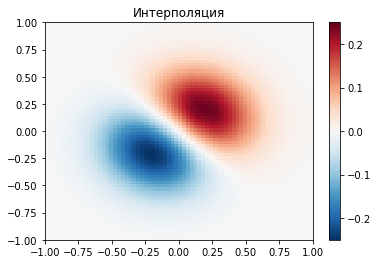

In [ ]:
#сетка 70 на 70
xnew_edges, ynew_edges = np.mgrid[-1:1:71j, -1:1:71j]
xnew = xnew_edges[:-1, :-1] + np.diff(xnew_edges[:2, 0])[0] / 2.
ynew = ynew_edges[:-1, :-1] + np.diff(ynew_edges[0, :2])[0] / 2.
tck = interpolate.bisplrep(x, y, z, s=0)
znew = interpolate.bisplev(xnew[:,0], ynew[0,:], tck)

plt.figure()
plt.pcolormesh(xnew_edges, ynew_edges, znew, shading='flat', **lims)
plt.colorbar()
plt.title("Интерполяция")
plt.show()

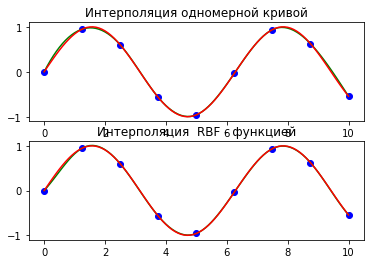

In [ ]:
# сглаживание при интерполяции
import numpy as np
from scipy.interpolate import Rbf, InterpolatedUnivariateSpline
import matplotlib.pyplot as plt

# setup data
x = np.linspace(0, 10, 9)
y = np.sin(x)
xi = np.linspace(0, 10, 101)

# use fitpack2 method
ius = InterpolatedUnivariateSpline(x, y)
yi = ius(xi)

plt.subplot(2, 1, 1)
plt.plot(x, y, 'bo')
plt.plot(xi, yi, 'g')
plt.plot(xi, np.sin(xi), 'r')
plt.title('Интерполяция одномерной кривой')

# use RBF method
rbf = Rbf(x, y)
fi = rbf(xi)

plt.subplot(2, 1, 2)
plt.plot(x, y, 'bo')
plt.plot(xi, fi, 'g')
plt.plot(xi, np.sin(xi), 'r')
plt.title('Интерполяция  RBF - функцией')
plt.show()

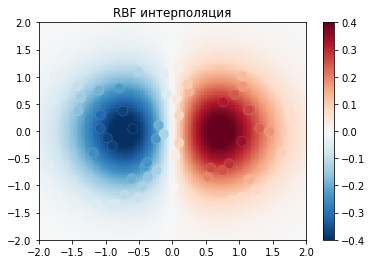

In [ ]:
import numpy as np
from scipy.interpolate import Rbf
import matplotlib.pyplot as plt
from matplotlib import cm

# 2-d tests - setup scattered data
x = np.random.rand(100)*4.0-2.0
y = np.random.rand(100)*4.0-2.0
z = x*np.exp(-x**2-y**2)
edges = np.linspace(-2.0, 2.0, 101)
centers = edges[:-1] + np.diff(edges[:2])[0] / 2.
XI, YI = np.meshgrid(centers, centers)

# use RBF
rbf = Rbf(x, y, z, epsilon=2)
ZI = rbf(XI, YI)

# plot the result
plt.subplot(1, 1, 1)
X_edges, Y_edges = np.meshgrid(edges, edges)
lims = dict(cmap='RdBu_r', vmin=-0.4, vmax=0.4)
plt.pcolormesh(X_edges, Y_edges, ZI, shading='flat', **lims)
plt.scatter(x, y, 100, z, edgecolor='w', lw=0.1, **lims)
plt.title('RBF интерполяция')
plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.colorbar()

**FFT**

In [ ]:
from scipy.fftpack import fft, ifft
x = np.array([0,1,2,3])
y = fft(x)
y
yy=y*y.conjugate()
yy

array([36.+0.j,  8.+0.j,  4.+0.j,  8.+0.j])

/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:2: UserWarning: In Matplotlib 3.3 individual lines on a stem plot will be added as a LineCollection instead of individual lines. This significantly improves the performance of a stem plot. To remove this warning and switch to the new behaviour, set the "use_line_collection" keyword argument to True.
  
/usr/local/lib/python3.6/dist-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)
/usr/local/lib/python3.6/dist-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


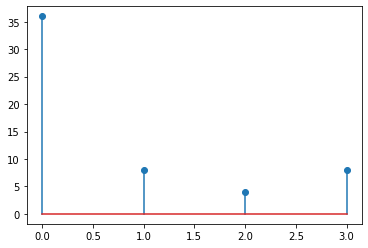

In [ ]:

plt.stem(x, yy)
plt.show()

In [ ]:
y2=ifft(y)
y2

array([0.+0.j, 1.+0.j, 2.-0.j, 3.+0.j])

/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:1: UserWarning: In Matplotlib 3.3 individual lines on a stem plot will be added as a LineCollection instead of individual lines. This significantly improves the performance of a stem plot. To remove this warning and switch to the new behaviour, set the "use_line_collection" keyword argument to True.
  """Entry point for launching an IPython kernel.
/usr/local/lib/python3.6/dist-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)
/usr/local/lib/python3.6/dist-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


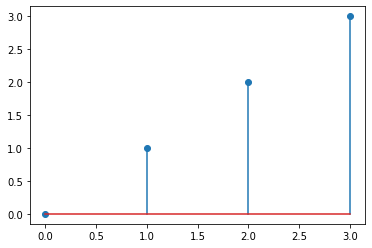

In [ ]:
plt.stem(x, y2)
plt.show()

In [ ]:
from scipy.fftpack import fft, ifft
x = np.array([0,1,2,3])
y = ifft(x)
y

array([ 1.5-0.j , -0.5-0.5j, -0.5-0.j , -0.5+0.5j])

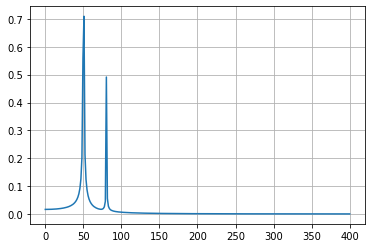

In [ ]:
from scipy.fft import fft
# Number of sample points
N = 600
# sample spacing
T = 1.0 / 800.0
x = np.linspace(0.0, N*T, N)
y = np.sin(50.0 * 2.0*np.pi*x) + 0.5*np.sin(80.0 * 2.0*np.pi*x)
yf = fft(y)
xf = np.linspace(0.0, 1.0/(2.0*T), N//2)
import matplotlib.pyplot as plt
plt.plot(xf, 2.0/N * np.abs(yf[0:N//2]))
plt.grid()
plt.show()

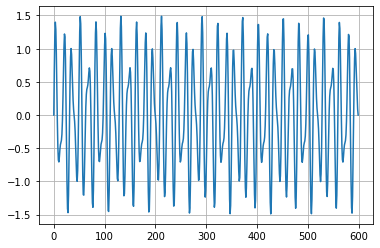

In [ ]:
plt.plot(y)
plt.grid()
plt.show()

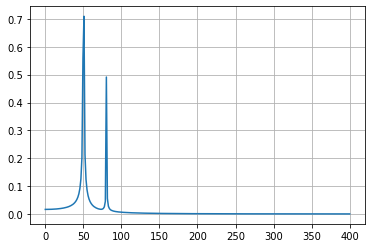

In [ ]:
from scipy.fft import fft
# Number of sample points
N = 600
# sample spacing
T = 1.0 / 800.0
x = np.linspace(0.0, N*T, N)
#y = np.sin(50.0 * 2.0*np.pi*x) + 2*np.sin(100.0 * 2.0*np.pi*x)+ 3*np.sin(150.0 * 2.0*np.pi*x)

yf = fft(y)
xf = np.linspace(0.0, 1.0/(2.0*T), N//2)
import matplotlib.pyplot as plt
plt.plot(xf, 2.0/N * np.abs(yf[0:N//2]))
plt.grid()
plt.show()

In [ ]:
# Подробнее https://cfd.spbstu.ru/agarbaruk/doc/Bach_2006_Reznik_Spectra.pdf

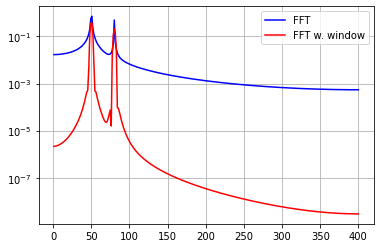

In [ ]:
# Number of sample points
N = 600
# sample spacing
T = 1.0 / 800.0
x = np.linspace(0.0, N*T, N)
y = np.sin(50.0 * 2.0*np.pi*x) + 0.5*np.sin(80.0 * 2.0*np.pi*x)
yf = fft(y)
from scipy.signal import blackman
w = blackman(N)
ywf = fft(y*w)
xf = np.linspace(0.0, 1.0/(2.0*T), N//2)
import matplotlib.pyplot as plt
plt.semilogy(xf[1:N//2], 2.0/N * np.abs(yf[1:N//2]), '-b')
plt.semilogy(xf[1:N//2], 2.0/N * np.abs(ywf[1:N//2]), '-r')
plt.legend(['FFT', 'FFT w. window'])
plt.grid()
plt.show()

In [ ]:
from scipy.fft import fftfreq
freq = fftfreq(8, 0.125)
freq

array([ 0.,  1.,  2.,  3., -4., -3., -2., -1.])

In [ ]:
from scipy.fft import fftshift
x = np.arange(8)
fftshift(x)

array([4, 5, 6, 7, 0, 1, 2, 3])

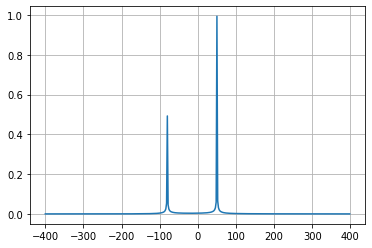

In [ ]:
from scipy.fft import fft, fftfreq, fftshift
# number of signal points
N = 400
# sample spacing
T = 1.0 / 800.0
x = np.linspace(0.0, N*T, N)
y = np.exp(50.0 * 1.j * 2.0*np.pi*x) + 0.5*np.exp(-80.0 * 1.j * 2.0*np.pi*x)
yf = fft(y)
xf = fftfreq(N, T)
xf = fftshift(xf)
yplot = fftshift(yf)
import matplotlib.pyplot as plt
plt.plot(xf, 1.0/N * np.abs(yplot))
plt.grid()
plt.show()

**Функции обработки сигналов.  Фильтрация**

In [ ]:
from scipy import signal
x = np.arange(35).reshape(7, 5)
domain = np.identity(3)
print(x,end='\n')
print(signal.order_filter(x, domain, 1))

[[ 0  1  2  3  4]
 [ 5  6  7  8  9]
 [10 11 12 13 14]
 [15 16 17 18 19]
 [20 21 22 23 24]
 [25 26 27 28 29]
 [30 31 32 33 34]]
[[ 0.  1.  2.  3.  0.]
 [ 5.  6.  7.  8.  3.]
 [10. 11. 12. 13.  8.]
 [15. 16. 17. 18. 13.]
 [20. 21. 22. 23. 18.]
 [25. 26. 27. 28. 23.]
 [ 0. 25. 26. 27. 28.]]


**Генерация сигналов**

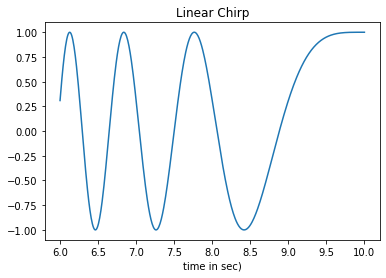

In [ ]:
from scipy.signal import chirp, spectrogram
import matplotlib.pyplot as plt
t = np.linspace(6, 10, 500)
w = chirp(t, f0=4, f1=2, t1=5, method='linear')
plt.plot(t, w)
plt.title("Linear Chirp")
plt.xlabel('time in sec)')
plt.show()

In [ ]:
# Корреляция
#равно 1 совершенная положительная линейная зависимость
#больше 0 положительная корреляция
#равна 0 независимая
#меньше 0 отрицательная корреляция
#равна -1 совершенная отрицательная линейная зависимость


In [ ]:
import numpy as np
x = np.arange(10, 20)


y = np.array([2, 1, 4, 5, 8, 12, 18, 25, 96, 48])
r = np.corrcoef(x, y)
r

array([[1.        , 0.75864029],
       [0.75864029, 1.        ]])

In [ ]:
r[0, 1]

0.7586402890911867

In [ ]:
r[1, 0]

0.7586402890911869

In [ ]:
r[1,1]

1.0

In [ ]:
#pearsonr()
#spearmanr()
#kendalltau()
import numpy as np
import scipy.stats
x = np.arange(10, 20)
y = np.array([2, 1, 4, 5, 8, 12, 18, 25, 96, 48])
scipy.stats.pearsonr(x, y)    # Pearson's r



(0.758640289091187, 0.010964341301680813)

In [ ]:
scipy.stats.pearsonr(y, x)

(0.758640289091187, 0.010964341301680813)

In [ ]:
scipy.stats.pearsonr(x, y)[0]

0.758640289091187

In [ ]:
 r, p = scipy.stats.pearsonr(x, y)
 r

0.758640289091187

In [ ]:
p

0.010964341301680813

In [ ]:
scipy.stats.spearmanr(x, y)   # Spearman's rho



SpearmanrResult(correlation=0.9757575757575757, pvalue=1.4675461874042197e-06)

In [ ]:
scipy.stats.spearmanr(x, y)[0]

0.9757575757575757

In [ ]:
scipy.stats.spearmanr(x, y).correlation

0.9757575757575757

In [ ]:
scipy.stats.kendalltau(x, y)  # Kendall's tau

KendalltauResult(correlation=0.911111111111111, pvalue=2.9761904761904762e-05)

In [ ]:
scipy.stats.kendalltau(x, y)[0]

0.911111111111111

In [ ]:
scipy.stats.kendalltau(x, y).correlation

0.911111111111111

In [ ]:
from scipy.stats import linregress
linregress(x, y)

LinregressResult(slope=7.4363636363636365, intercept=-85.92727272727274, rvalue=0.7586402890911869, pvalue=0.010964341301680825, stderr=2.257878767543913)

In [ ]:
a = [15, 12, 8, 8, 7, 7, 7, 6, 5, 3]
b = [10, 25, 17, 11, 13, 17, 20, 13, 9, 15]
from scipy.stats import linregress
linregress(a, b)
#slope: наклон линии регрессии
#intercept: перехват линии регрессии
#rvalue: коэффициент корреляции
#pvalue : двустороннее p-значение для проверки гипотезы, чья гипотеза null состоит в том, что наклон равен нулю
#stderr: Стандартная ошибка оценки

LinregressResult(slope=0.20833333333333331, intercept=13.375, rvalue=0.14499815458068518, pvalue=0.689401448116695, stderr=0.5026170462708364)

In [ ]:
import pandas as pd
x = pd.Series(range(10, 20))
y = pd.Series([2, 1, 4, 5, 8, 12, 18, 25, 96, 48])
x.corr(y)  #r

0.7586402890911867

In [ ]:
y.corr(x)

0.7586402890911869

In [ ]:
x.corr(y, method='spearman')

0.9757575757575757

In [ ]:
x.corr(y, method='kendall')

0.911111111111111

In [ ]:
#Подробнее можно увидеть в https://www.machinelearningmastery.ru/statistical-hypothesis-tests-in-python-cheat-sheet/

In [ ]:
# Спектральная плотность

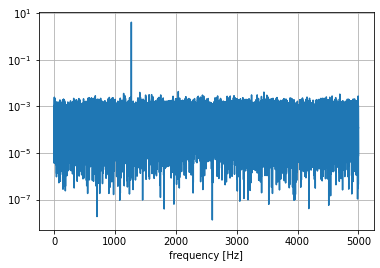

In [ ]:
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt

fs = 10e3
N = 1e5
amp = 2*np.sqrt(2)
freq = 1270.0
noise_power = 0.001 * fs / 2
time = np.arange(N) / fs
x = amp*np.sin(2*np.pi*freq*time)
x += np.random.normal(scale=np.sqrt(noise_power), size=time.shape)

f, Pper_spec = signal.periodogram(x, fs, 'flattop', scaling='spectrum')

plt.semilogy(f, Pper_spec)
plt.xlabel('frequency [Hz]')
plt.ylabel('')
plt.grid()
plt.show()

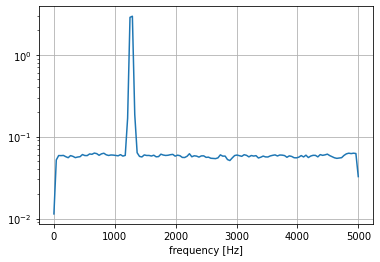

In [ ]:
#  метод Уэлча
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt

fs = 10e3
N = 1e5
amp = 2*np.sqrt(2)
freq = 1270.0
noise_power = 0.001 * fs / 2
time = np.arange(N) / fs
x = amp*np.sin(2*np.pi*freq*time)
x += np.random.normal(scale=np.sqrt(noise_power), size=time.shape)

f, Pwelch_spec = signal.welch(x, fs, scaling='spectrum')

plt.semilogy(f, Pwelch_spec)
plt.xlabel('frequency [Hz]')
plt.ylabel('')
plt.grid()
plt.show()

In [ ]:
#подробнее http://kprf.mipt.ru/attachments/article/57/лекция_2017_03_13.pdf

/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:25: DeprecationWarning: `hanning` is deprecated, use `scipy.signal.windows.hann` instead!
/usr/local/lib/python3.6/dist-packages/scipy/signal/spectral.py:1815: UserWarning: Input data is complex, switching to return_onesided=False
  warnings.warn('Input data is complex, switching to '


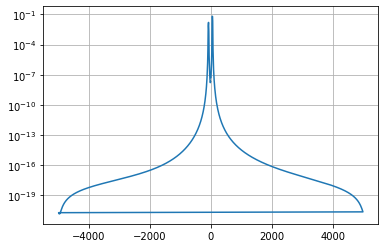

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch, hanning

#x = np.linspace(0, 1000)
x = np.linspace(0, 10, 100001)
dt = x[1] - x[0]
fs = 1 / dt

a1 = 1
f1 = 500

a2 = 10
f2 = 2000

#y = a1 * np.sin(2*np.pi*f1*x) + a2 * np.sin(2*np.pi*f2*x)
y = np.exp(50.0 * 1.j * 2.0*np.pi*x) + 0.5*np.exp(-80.0 * 1.j * 2.0*np.pi*x)

data = y

nblock = 1024
#nblock=100
overlap = 128
#overlap=4
win = hanning(nblock, True)

f, Pxxf = welch(data, fs, window=win, noverlap=overlap, nfft=nblock, return_onesided=True, detrend=False)

plt.semilogy(f, Pxxf, '-')

plt.grid()
plt.show()

In [ ]:
#https://pyprog.pro/
#https://docs.scipy.org/doc/scipy/reference/tutorial/index.html
#https://pythonru.com/
#https://realpython.com/numpy-scipy-pandas-correlation-python/
 #https://habr.com/ru/post/460445/
